# testSCVIbatch.ipynb — cross-batch pair-MSE alignment loss

Inherits from `testRUVVAE_ZINB.ipynb` (uses the same TH subset + scVI-style
data prep). Calls [`model_scvi_batch_pair.SCVIWithBatchPairLoss`](model_scvi_batch_pair.py)
which adds an extra cross-batch MSE term to the standard scVI loss.

Pipeline:
1. Load data & prepare scVI format (counts in X, n_genes_on covariate)
2. `setup_anndata` + build `SCVIWithBatchPairLoss`
3. Forward validation: `pair_loss > 0` only when mini-batch has ≥ 2 batches
4. Train (100 epochs), watch `batch_pair_mse`
5. Evaluate alignment: iLISI / ASW vs baseline SCVI
6. Visualise: UMAP by batch, per-pair MSE convergence, latent `z` distribution

In [1]:
from scipy.sparse import csr_matrix, issparse
import numpy as np
import scanpy as sc
import pandas as pd


In [2]:
# ========== Load the same data subset as testRUVVAE_ZINB.ipynb ==========

adata = sc.read_h5ad(
    "/data8/junyi/pubdata/transformed/GSE118767_batchscvifix/GSE118767_batchscvifix_full.h5ad")

# adata_subset = adata[
#     adata.obs["celltype.L2"].isin(
#         adata.obs["celltype.L2"].value_counts().head(2).index[1:2]
#     )
# ]
# adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]

print(f"adata_subset shape: {adata.shape}")
# print(f"status counts:\n{adata.obs['status'].value_counts()}")
# print(f"company counts:\n{adata.obs['company'].value_counts()}")

adata_subset shape: (4843, 41442)


In [3]:
adata

AnnData object with n_obs × n_vars = 4843 × 41442
    obs: 'protocol', 'title', 'source name', 'organism', 'barcode', 'barcode_dropseq', 'n_reads_dropseq', 'source_file', 'sample_id', 'n_genes_on', '_scvi_batch', '_scvi_labels', 'metadata_matched', '__meta_barcode__', 'meta_unaligned', 'meta_aligned_unmapped', 'meta_mapped_to_exon', 'meta_mapped_to_intron', 'meta_ambiguous_mapping', 'meta_mapped_to_ERCC', 'meta_mapped_to_MT', 'meta_number_of_genes', 'meta_total_count_per_cell', 'meta_non_ERCC_percent', 'meta_non_mt_percent', 'meta_non_ribo_percent', 'meta_outliers', 'meta_cell_name', 'meta_p_column', 'meta_p_row', 'meta_mix', 'meta_H2228_prop', 'meta_H1975_prop', 'meta_HCC827_prop', 'meta_mRNA_amount', 'meta_H1975', 'meta_H2228', 'meta_HCC827', 'meta_poor_quality', 'meta_traj', 'meta_is_cell_control', 'meta_total_features_by_counts', 'meta_log10_total_features_by_counts', 'meta_total_counts', 'meta_log10_total_counts', 'meta_pct_counts_in_top_50_features', 'meta_pct_counts_in_top_100_f

In [4]:
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)


/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


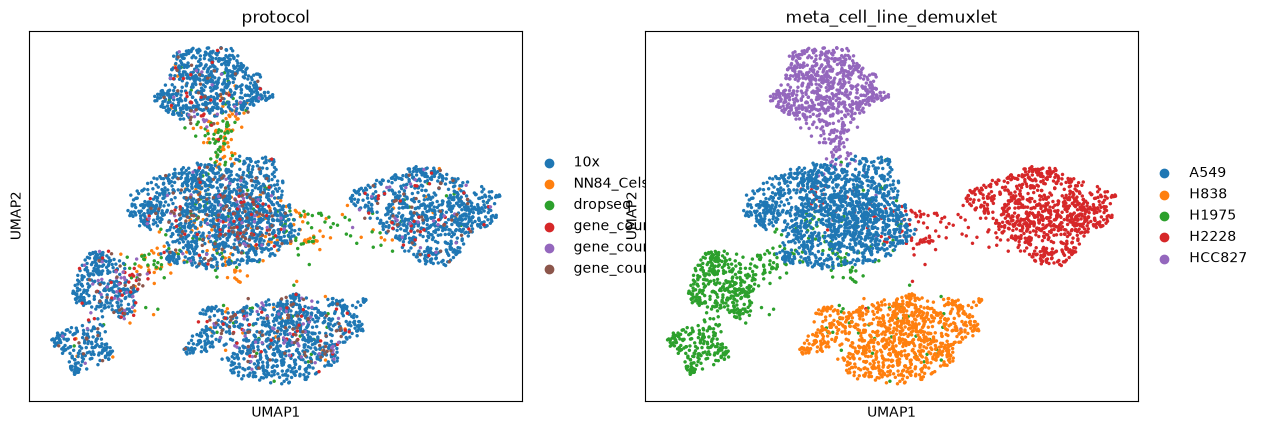

In [5]:
sc.pl.umap(adata, color=["protocol","meta_cell_line_demuxlet"])

In [27]:
LAYER_NAME = "scvi_nrom_counts"
COUNT_LAYER_NAME = "scvi_reconstructed_counts"

In [ ]:
adata.X.max()

In [ ]:
adata.layers['scvi_reconstructed_counts'].max()

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [ ]:
adata.var

In [ ]:
# ENSG -> gene symbol：通过 BioMart 拉取完整映射再本地 merge（不传 filter，避免 Unknown filter）
import pybiomart as pbm

dataset = pbm.Dataset(
    name="hsapiens_gene_ensembl",
    host="http://www.ensembl.org",
)
full_map = dataset.query(
    attributes=["ensembl_gene_id", "external_gene_name"],
)
full_map.columns = ["ensg", "symbol"]
full_map["ensg"] = full_map["ensg"].astype(str)
full_map = full_map.dropna(subset=["symbol"]).drop_duplicates("ensg")
print(f"BioMart 全量映射共 {len(full_map)} 行")

# 保留 adata.var_names 的原始 ENSG（包括可能存在的版本号），并给未命中的 ID 回退原值
df_map = pd.DataFrame({"ensg": adata.var_names.astype(str)})
df_map["ensg_query"] = df_map["ensg"].str.split(".").str[0]
df_map = df_map.merge(
    full_map.rename(columns={"ensg": "ensg_query"}),
    on="ensg_query", how="left").drop(columns="ensg_query")
df_map["symbol"] = df_map["symbol"].fillna(df_map["ensg"])
df_map["gene_name"] = df_map["symbol"]

nsymbol = df_map["symbol"].ne(df_map["ensg"]).sum()
print(f"本地匹配 {nsymbol} 个 ENSG -> symbol")
df_map.head()

In [ ]:
full_map

In [ ]:
full_map

In [ ]:
adata.var['gene_symbol'] = adata.var_names.copy()

In [ ]:
adata.var['gene_symbol'] = adata.var['gene_symbol'].astype("str")

In [ ]:
dict_ensg_map = dict(zip(full_map['ensg'], full_map['symbol']))

In [ ]:
adata.var['gene_id'] = adata.var_names

In [ ]:
dict_ensg_map

In [ ]:
adata.var['gene_symbol'] = adata.var['gene_id'].str.split('.').str[0].map(dict_ensg_map)

In [ ]:
adata.var

In [ ]:
adata.var.loc[adata.var['gene_symbol'].isna(),"gene_symbol"] = adata.var.loc[adata.var['gene_symbol'].isna(),"gene_id"].values

In [ ]:
sc.pp.neighbors(adata, use_rep="X_harmony")
sc.tl.umap(adata)
sc.pp.log1p(adata)

In [ ]:
adata.var_names = adata.var['gene_symbol'].values

In [ ]:
adata.var_names

In [ ]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "FCER1A", "CST3", "PPBP"],
]


In [ ]:
df_meta = pd.read_csv('/data1st1/junyi/correctdata/GSE133549/HCA_meta.csv', index_col=0 )

In [ ]:
df_meta.nnet2.value_counts()

In [ ]:
df_merge = pd.merge(adata.obs, df_meta, left_index=True, right_index=True, how='left')

In [ ]:
df_back = adata.obs.copy()

In [ ]:
df_merge

In [ ]:
adata.obs = df_merge

In [ ]:
marker_list = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

In [ ]:
sc.pl.umap(
    adata,
    color=["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    # Setting a smaller point size to get prevent overlap
    ncols=2,
    size=10,
)


In [ ]:
sc.pl.umap(
    adata,
    color=["nnet2","sample_id"],
    # Setting a smaller point size to get prevent overlap
    ncols=2,
    size=10,
)


In [ ]:
sc.pl.umap(
    adata,
    color=["sample_id"],
    # Setting a smaller point size to get prevent overlap
    ncols=2,
    size=10,
)


In [ ]:
adata_subset = adata[~adata.obs["nnet2"].isna()]

In [ ]:
adata_subset.write_h5ad("/data1st1/junyi/correctdata/GSE133549/HCA_subset.h5ad")

In [ ]:
adata_subset.layers['counts'].max()

In [ ]:
sc.pl.umap(
    adata_subset,
    color=["sample_id"],
    # Setting a smaller point size to get prevent overlap
    ncols=2,
    size=10,
)


In [ ]:
adata_sub=adata[adata.obs.meta_demuxlet_cls=="SNG"]

In [ ]:
adata_sub.obs['meta_outliers'] = adata_sub.obs['meta_outliers'].astype(bool)
adata_sub.obs['meta_is_cell_control'] = adata_sub.obs['meta_is_cell_control'].astype(bool)


In [ ]:
adata_sub.write_h5ad("/data1st1/junyi/correctdata/transformed/GSE118767_scviharmony/GSE118767subset_scviHarmony.h5ad")

In [ ]:
adata_sub = sc.read_h5ad("//data1st1/junyi/correctdata/publicdata/GSE118767.h5ad")

In [ ]:
adata_sub.obs

In [ ]:
sc.pl.umap(
    adata,
    color=["meta_cell_line","protocol","meta_H1975","meta_H2228","meta_HCC827"],
    # Setting a smaller point size to get prevent overlap
    ncols=2,
    size=10,
)


In [ ]:
sc.pl.umap(
    adata,
    color=["meta_cell_line","protocol","meta_H2228_prop","meta_HCC827_prop"],
    # Setting a smaller point size to get prevent overlap
    ncols= 2,
    size=10,
)


In [ ]:
sc.pl.umap(
    adata,
    color=["EGFR", "EPCAM", "KRT7", "KRT8", "KRT18", "KRT19", "CDH1"],
    # Setting a smaller point size to get prevent overlap
    size=10,
)


In [ ]:
seen = set()
hkg_genes = []
for g in hkg_priority:
    if g in adata.var_names and g not in seen:
        seen.add(g)
        hkg_genes.append(g)

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="protocol",
    layer="scvi_nrom_counts_harmony",
)
fig.show()


In [ ]:

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="sample",
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
)
fig.show()


In [ ]:
# print the max,min,mean value of the normalized in batchpair_D1_normlized 
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.X.max()}")
print(f"Min value in adata.X: {adata.X.min()}")
print(f"Mean value in adata.X: {adata.X.mean()}")


In [ ]:
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.layers['scvi_norm'].max()}")
print(f"Min value in adata.X: {adata.layers['scvi_norm'].min()}")
print(f"Mean value in adata.X: {adata.layers['scvi_norm'].mean()}")


In [ ]:
sc.pp.log1p(adata)

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="company", method="wilcoxon",pct=True)

In [ ]:
df_all = pd.DataFrame()
for company in adata.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata, group=company)
    df_company["company"] = company
    df_all = pd.concat([df_all, df_company], ignore_index=True)

In [ ]:
df_all_filtered = df_all[df_all["pvals_adj"] < 0.05]

In [ ]:
df_all_filtered.value_counts("company")

In [ ]:
adata.layers["log1px"] = adata.X.copy()

In [ ]:
adata.X = adata.layers[LAYER_NAME].copy()

In [ ]:
sc.pp.log1p(adata)

In [ ]:
adata.layers["log1pscvi"] = adata.X.copy()

In [ ]:
adata_con = adata[adata.obs["Model"] == "CON_M"]

In [ ]:
adata_con.X = adata_con.layers["log1pscvi"].copy()
sc.tl.rank_genes_groups(adata_con, groupby="company", method="wilcoxon",pct=True)

In [ ]:
df_con_correct = pd.DataFrame()
for company in adata_con.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata_con, group=company)
    df_company["company"] = company
    df_con_correct = pd.concat([df_con_correct, df_company], ignore_index=True)

In [ ]:
df_con_correct_filtered = df_con_correct[df_con_correct["pvals_adj"] < 0.05]
df_con_correct_filtered.value_counts("company")

In [ ]:
adata_con.X = adata_con.layers["log1px"].copy()
sc.tl.rank_genes_groups(adata_con, groupby="company", method="wilcoxon",pct=True)


In [ ]:
df_raw = pd.DataFrame()
for company in adata_con.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata_con, group=company)
    df_company["company"] = company
    df_raw = pd.concat([df_raw, df_company], ignore_index=True)
df_raw_filtered = df_raw[df_raw["pvals_adj"] < 0.05]
print(f"Number of significant genes for each company:\n{df_raw_filtered.value_counts('company')}")

In [ ]:
df_raw_filtered['absFC'] = df_raw_filtered['logfoldchanges'].abs()
df_con_correct_filtered['absFC'] = df_con_correct_filtered['logfoldchanges'].abs()

In [ ]:
df_raw_filtered.groupby('company').agg({'absFC': ['mean', 'std']})

In [ ]:
df_con_correct_filtered.groupby('company').agg({'absFC': ['mean', 'std']})

In [ ]:
# df_status_raw = pd.DataFrame()
# adata.X = adata.layers["log1px"].copy()
# for status in adata.obs.status.unique():
#     adata_disease = adata[(adata.obs.status == status) | (adata.obs.status == "CON") ]
#     sc.tl.rank_genes_groups(adata_disease, groupby="status", method="wilcoxon",pct=True)
#     df_status_tmp = sc.get.rank_genes_groups_df(adata_disease, group=status)
#     df_status_tmp["status"] = status
#     df_status_raw = pd.concat([df_status_raw, df_status_tmp], ignore_index=True)
# df_status_raw_filtered = df_status_raw[df_status_raw["pvals_adj"] < 0.05]
# df_status_raw_filtered['Direction'] = df_status_raw_filtered['logfoldchanges'].apply(lambda x: 'up' if x > 0 else 'down')

In [ ]:
# df_status_corrected = pd.DataFrame()
# adata.X = adata.layers["log1pscvi"].copy()
# for status in adata.obs.status.unique():
#     adata_disease = adata[(adata.obs.status == status) | (adata.obs.status == "CON")]
#     sc.tl.rank_genes_groups(adata_disease, groupby="status", method="wilcoxon", pct=True)
#     df_status_tmp = sc.get.rank_genes_groups_df(adata_disease, group=status)
#     df_status_tmp["status"] = status
#     df_status_corrected = pd.concat([df_status_corrected, df_status_tmp], ignore_index=True)
# df_status_corrected_filtered = df_status_corrected[df_status_corrected["pvals_adj"] < 0.05]

In [ ]:
mouse_brain_hkg = [
    # === 结构/骨架（必须有）===
    "Actb",          # β-actin
    "Tuba1a",        # α-tubulin
    "Ubc",           # ubiquitin
    "Uba52",         # ubiquitin-60S ribosomal
    # === 蛋白酶体/折叠（稳定）===
    "Psmd6", "Psmd7", "Psma5",
    "Hsp90aa1", "Hsp90ab1",  # Hsp90 伴侣
    "Ywhaz",              # 14-3-3ζ
    # === 线粒体（log-normalize 数据里必须加）===
    "Sdha", "Cyc1",
    "Cox4i1", "Cox5b",
    "Ndufa4", "Ndufb8",
    "Atp5f1b",
    # === 翻译机器（精选）===
    "Eef1a1",
    "Rplp0", "Rpl19", "Rps18",   # 比 Rps13/Rps20 稳
    "Polr2a",
    # === 转录机器 ===
    "Tbp",
    # === 代谢稳定 ===
    "Ppia", "Pgk1",
]

In [ ]:
adata_con.obs

In [ ]:
# 自包含：本 cell 重新准备 CON 内的 raw / corrected 表达矩阵
from sklearn.metrics import roc_auc_score
from scipy.sparse import issparse

con_company = adata_con.obs["company"].values
companies = sorted(set(con_company))

X_raw_con = adata_con.layers["log1px"]
X_corr_con = adata_con.layers["log1pscvi"]
if issparse(X_raw_con):
    X_raw_con = X_raw_con.toarray()
if issparse(X_corr_con):
    X_corr_con = X_corr_con.toarray()
X_raw_con = np.asarray(X_raw_con)
X_corr_con = np.asarray(X_corr_con)


def per_company_aucs(x_col, y_label, comps):
    """对单基因，返回每个 company one-vs-rest 的 abs(AUC-0.5)+0.5（dict）。"""
    out = {}
    for comp in comps:
        y = (y_label == comp).astype(int)
        if y.sum() == 0 or y.sum() == len(y):
            out[comp] = np.nan
            continue
        try:
            a = roc_auc_score(y, x_col)
        except ValueError:
            out[comp] = np.nan
            continue
        out[comp] = abs(a - 0.5) + 0.5
    return out


hkg_in_data = [g for g in mouse_brain_hkg if g in adata_con.var_names]
print(f"hkg_priority 共 {len(mouse_brain_hkg)} 个，adata_con 中存在 {len(hkg_in_data)} 个")
print(f"companies: {companies}")
print(f"company 分布: {dict(zip(*np.unique(con_company, return_counts=True)))}\n")

# 每个基因 × 每个 company 都算 AUC，存成 long-form DataFrame
rows = []
for g in hkg_in_data:
    col = list(adata_con.var_names).index(g)
    raw_a = per_company_aucs(X_raw_con[:, col],  con_company, companies)
    cor_a = per_company_aucs(X_corr_con[:, col], con_company, companies)
    for comp in companies:
        rows.append({
            "gene": g,
            "company": comp,
            "raw_AUC":  raw_a.get(comp, np.nan),
            "corr_AUC": cor_a.get(comp, np.nan),
            "delta":    cor_a.get(comp, np.nan) - raw_a.get(comp, np.nan),
        })

hkg_auc_df = pd.DataFrame(rows)

# 再算每基因的 best（三个公司 AUC 的最大值）作为汇总列
best_per_gene = (
    hkg_auc_df.groupby("gene")[["raw_AUC", "corr_AUC"]]
    .max()
    .rename(columns={"raw_AUC": "best_raw", "corr_AUC": "best_corr"})
    .reset_index()
)
best_per_gene["delta_best"] = best_per_gene["best_corr"] - best_per_gene["best_raw"]
hkg_auc_df = hkg_auc_df.merge(best_per_gene, on="gene", how="left")

print("=== 每个 HK 基因 × 每个 company 的 raw / corr AUC ===")
print(hkg_auc_df.to_string(index=False))

# 汇总：每个公司的 raw / corr AUC 均值
print("\n=== 按 company 汇总（mean ± std）===")
summary_by_comp = (
    hkg_auc_df.groupby("company")
    .agg(
        n=("gene", "count"),
        raw_mean=("raw_AUC", "mean"),
        raw_std=("raw_AUC", "std"),
        corr_mean=("corr_AUC", "mean"),
        corr_std=("corr_AUC", "std"),
        delta_mean=("delta", "mean"),
        frac_raw_gt_0_6=("raw_AUC", lambda s: (s > 0.6).mean()),
        frac_corr_gt_0_6=("corr_AUC", lambda s: (s > 0.6).mean()),
    )
    .round(4)
    .reset_index()
)
print(summary_by_comp.to_string(index=False))

print("\n=== best across companies（每基因三公司最大 AUC）===")
print(best_per_gene.to_string(index=False))

# best 的整体 mean
print(
    f"\n整体 best: raw mean={best_per_gene['best_raw'].mean():.3f}  "
    f"corr mean={best_per_gene['best_corr'].mean():.3f}  "
    f"Δ={best_per_gene['delta_best'].mean():+.3f}"
)
hkg_auc_df

In [ ]:
# ============================================================================
# 每个 company raw DEG 的 top-10，做该 company vs other companies 的 AUC
# 每一行 = 一个 company 的一个 top DEG，不再区分 source_company / test_company
# ============================================================================
TOP_N = 10


def top_n_genes_per_company_from_df(df, group_col, gene_col, lfc_col, n=TOP_N):
    """从已过滤的 DEG DataFrame 取每个 company 的 top-N 基因。"""
    out = {}
    for company, sub in df.groupby(group_col):
        ranked = sub.assign(_abs_logfc=sub[lfc_col].abs())
        ranked = ranked.sort_values("_abs_logfc", ascending=False)
        out[company] = ranked.head(n).copy()
    return out


# df_raw_filtered 已按 pvals_adj < 0.05 过滤
_top10_per_company = top_n_genes_per_company_from_df(
    df_raw_filtered,
    group_col="company",
    gene_col="names",
    lfc_col="logfoldchanges",
    n=TOP_N,
)

_var_index = {gene: i for i, gene in enumerate(adata_con.var_names)}
_top10_rows = []
for company, company_df in _top10_per_company.items():
    for _, gene_row in company_df.iterrows():
        gene = str(gene_row["names"])
        if gene not in _var_index:
            continue
        col = _var_index[gene]

        # 只计算该 company vs all other companies 的 one-vs-rest AUC
        y_company = (con_company == company).astype(int)
        raw_auc = abs(roc_auc_score(y_company, X_raw_con[:, col]) - 0.5) + 0.5
        corr_auc = abs(roc_auc_score(y_company, X_corr_con[:, col]) - 0.5) + 0.5

        _top10_rows.append({
            "company": company,
            "gene": gene,
            "raw_logFC": float(gene_row["logfoldchanges"]),
            "raw_AUC": raw_auc,
            "corr_AUC": corr_auc,
            "delta": corr_auc - raw_auc,
        })

top10_auc_df = pd.DataFrame(_top10_rows).sort_values(
    ["company", "raw_logFC"],
    key=lambda s: s.abs() if s.name == "raw_logFC" else s,
    ascending=[True, False],
).reset_index(drop=True)

summary_top10_by_company = (
    top10_auc_df.groupby("company")
    .agg(
        n=("gene", "count"),
        raw_mean=("raw_AUC", "mean"),
        raw_std=("raw_AUC", "std"),
        corr_mean=("corr_AUC", "mean"),
        corr_std=("corr_AUC", "std"),
        delta_mean=("delta", "mean"),
        frac_raw_gt_0_6=("raw_AUC", lambda s: (s > 0.6).mean()),
        frac_corr_gt_0_6=("corr_AUC", lambda s: (s > 0.6).mean()),
    )
    .round(4)
    .reset_index()
)

print(f"top10_auc_df shape: {top10_auc_df.shape}")
print(f"summary_top10_by_company shape: {summary_top10_by_company.shape}")

top10_auc_df